In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack, csr_matrix
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
combined_df = pd.read_csv("scraping/social_media/Combined_Dataset.csv")
combined_df

,Title,URL,Score,Upvote_Ratio,Num_Comments,Post_Date,AI_Post
0,Protests break out in major cities over new ta...,https://www.reddit.com/r/politics/comments/pos...,666,0.90,4646,03-27-2026,1
1,ABC pulls Taylor Frankie Paul's season of 'Bac...,https://www.nbcnews.com/pop-culture/pop-cultur...,6345,0.96,666,2026-03-19,0
2,Researchers uncover unusual pattern in Arctic ...,https://www.apnews.com/article/arctic-sea-ice-...,3960,0.73,1497,2026-04-02,1
3,Heavy metal memorabilia on offer at Julien's '...,https://www.reuters.com/business/media-telecom...,2475,0.82,238,2026-03-19,1
4,Rays RHP Ryan Pepiot (hip) to begin season on ...,https://www.reuters.com/sports/rays-rhp-ryan-p...,2457,0.72,148,2026-03-15,1
...,...,...,...,...,...,...,...
1201,US federal jury convicts Assad-era Syrian offi...,https://www.reuters.com/world/us-federal-jury-...,148,0.91,20,2026-03-17,0
1202,Air Canada flight hits vehicle on runway at La...,https://edition.cnn.com/2026/03/23/us/laguardi...,1433,0.96,166,2026-03-23,0
1203,Florida bill against marrying your first cousi...,https://www.ctvnews.ca/world/article/florida-b...,3923,0.94,419,2026-03-17,0
1204,Exclusive: Iran wants 'serious review' of Gulf...,https://www.reuters.com/world/middle-east/iran...,601,0.93,128,2026-03-16,0


**Extract `Year`, `Month`, and `Day` from `Post_Date`.**

In [3]:
if "Post_Date" in combined_df.columns:
    # Convert 'Post_Date' to datetime objects
    combined_df['Post_Date'] = pd.to_datetime(combined_df['Post_Date'], format='mixed', dayfirst=False)
    
    # Extract 'Year', 'Month', and 'Day' from 'Post_Date'
    combined_df['Year'] = combined_df['Post_Date'].dt.year
    combined_df['Month'] = combined_df['Post_Date'].dt.month
    combined_df['Day'] = combined_df['Post_Date'].dt.day
    
    # Drop 'Post_Date' and place 'AI_Post' (target variable) as last column
    combined_df.drop("Post_Date", axis=1, inplace=True)
    combined_df["AI_Post"] = combined_df.pop("AI_Post")

combined_df.dtypes

Title            object
URL              object
Score             int64
Upvote_Ratio    float64
Num_Comments      int64
Year              int32
Month             int32
Day               int32
AI_Post           int64
dtype: object

**Logistic Regression (Baseline Classification Model)**
- Only use numeric features (`Score`, `Upvote_Ratio`, `Num_Comments`, `Month`, `Day`) to predict AI_Post.
- Logistic Regression is the right baseline here because it's fast and interpretable.

In [4]:
X = combined_df[['Score', 'Upvote_Ratio', 'Num_Comments', 'Month', 'Day']] # Ignore `Year` since it is always 2026
y = combined_df['AI_Post']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=881)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Human (0)', 'AI (1)']))

              precision    recall  f1-score   support

   Human (0)       0.84      0.94      0.89       153
      AI (1)       0.93      0.82      0.87       149

    accuracy                           0.88       302
   macro avg       0.89      0.88      0.88       302
weighted avg       0.89      0.88      0.88       302



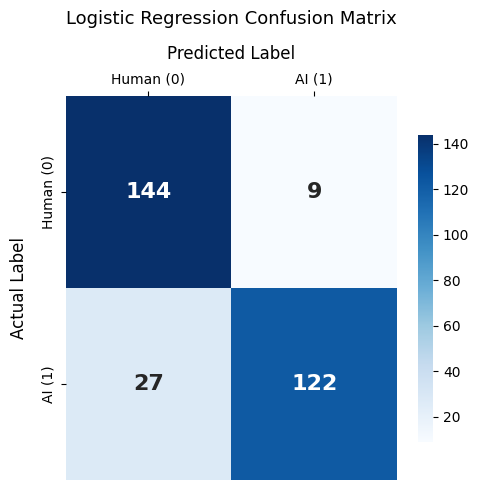

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Human (0)', 'AI (1)'], yticklabels=['Human (0)', 'AI (1)'],
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 16, 'weight': 'bold'}, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Logistic Regression Confusion Matrix', fontsize=13, pad=15)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()

**TF-IDF + XGBoost (High-Level Classification Model)**

`Title` is likely where the strongest signal lives, since AI-generated text has detectable stylistic patterns.
- TF-IDF vectorize the `Title` text to capture word/phrase frequency patterns.
- Combine those text features with the numeric features (`Score`, `Upvote_Ratio`, `Num_Comments`, `Month`, `Day`).
- Feed into XGBoost, which handles mixed feature types well and tends to outperform simpler models on tabular + text combinations.

In [6]:
numeric = combined_df[['Score', 'Upvote_Ratio', 'Num_Comments', 'Month', 'Day']].values # Ignore `Year` since it is always 2026

# TF-IDF on Title (unigrams + bigrams, top 5000 features)
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000,
                        sublinear_tf=True, stop_words='english')
title_tfidf = tfidf.fit_transform(combined_df['Title'])

# Scale numeric features, then combine with title_tfidf
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric)
X = hstack([csr_matrix(numeric_scaled), title_tfidf])
y = combined_df['AI_Post']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=881)

model = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                          eval_metric='logloss', random_state=881)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Human (0)', 'AI (1)']))

              precision    recall  f1-score   support

   Human (0)       0.95      0.96      0.95       153
      AI (1)       0.96      0.95      0.95       149

    accuracy                           0.95       302
   macro avg       0.95      0.95      0.95       302
weighted avg       0.95      0.95      0.95       302



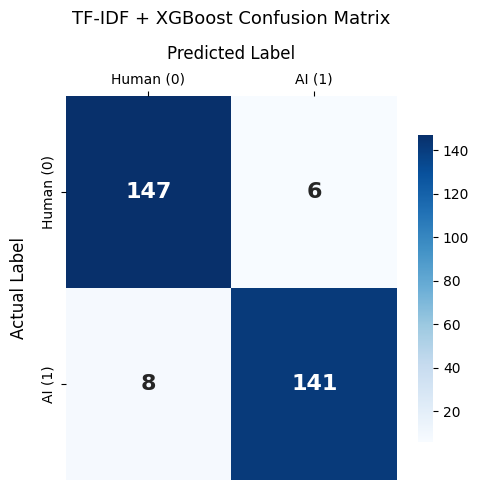

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Human (0)', 'AI (1)'], yticklabels=['Human (0)', 'AI (1)'],
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 16, 'weight': 'bold'}, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('TF-IDF + XGBoost Confusion Matrix', fontsize=13, pad=15)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()

**Conclusion:** In terms of average F1-Score, the jump from 88% to 95% confirms that `Title` carries strong predictive power when classifying a post as AI or non-AI. Both classes, Human (`AI_Post` = 0) and AI (`AI_Post` = 1), are now perfectly balanced in performance (0.95 F1-Score each), meaning the model is not biased toward either label.